# Etapa 2 (v2) — Modelagem Avançada de Churn com SMOTE e Benchmark de Inferência

**Objetivo:** superar o baseline (LogReg L2, AUC 0,8488 / Recall 0,7807) **sem sacrificar Precision**.

O modelo anterior (GradientBoosting + threshold 0,159) atingiu Recall 0,928 mas **Precision caiu para 0,44** — 437 clientes acionados sem necessidade a cada 1.409 avaliados. Esta versão redefine o critério de seleção para privilegiar **Precision ≥ 0,65** mantendo Recall alto, usa **SMOTE-NC** para balanceamento sem hack de threshold, compara 5 algoritmos em condições equivalentes e adiciona **latência de predição** como métrica de decisão.

### Mudanças em relação à v1
| Item | v1 | v2 |
|---|---|---|
| Balanceamento | `class_weight='balanced'` em alguns modelos | **SMOTE-NC** dentro do CV (imblearn.Pipeline) |
| Critério de seleção | AUC-ROC médio (empate estatístico) | **F1** no CV + Precision-floor no threshold |
| Threshold | 0,159 (Precision colapsa para 0,44) | Maximiza Recall com **Precision ≥ 0,65** |
| Comparação | 4 modelos com configs desiguais | 5 modelos com pipeline equivalente |
| Tempo de inferência | não medido | **Benchmark ms/amostra e throughput** |
| Reprodutibilidade | seeds parciais | seeds em split, CV, SMOTE, RandomizedSearch, modelos |

## 2.1 — Setup e Reprodutibilidade

In [1]:
import warnings, os, time, joblib
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                      cross_validate, RandomizedSearchCV,
                                      cross_val_predict)
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               HistGradientBoostingClassifier, ExtraTreesClassifier)
from sklearn.metrics import (classification_report, roc_auc_score, f1_score,
                              precision_score, recall_score, average_precision_score,
                              precision_recall_curve, roc_curve,
                              ConfusionMatrixDisplay)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTENC

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', None)

RANDOM_STATE = 42
TEST_SIZE    = 0.20
np.random.seed(RANDOM_STATE)

## 2.2 — Carregamento e Feature Engineering

Mantém as features derivadas validadas na v1 (`qtd_addons`, `contrato_longo`, `pagamento_automatico`, `internet_fibra`) e remove `Total Charges` (colinear com `Tenure Months`, ρ=0,826).

In [2]:
DATA_PATH  = '../data/raw/telco_customer_churn.xlsx'
SHEET_NAME = 'Telco_Churn'
TARGET_COL = 'Churn Value'

EXCLUDE_COLS = [
    'CustomerID', 'Count',
    'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude',
    'Churn Label', 'Churn Score', 'CLTV', 'Churn Reason',
]

df_raw = pd.read_excel(DATA_PATH, sheet_name=SHEET_NAME)
df_raw['Total Charges'] = pd.to_numeric(df_raw['Total Charges'], errors='coerce')

DROP_LOW_ASSOC = ['Gender', 'Phone Service']  # Cramér's V < 0.02
ADDON_COLS = ['Online Security', 'Online Backup', 'Device Protection',
              'Tech Support', 'Streaming TV', 'Streaming Movies']

def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # ── Correções pós-EDA (aplicadas também ao baseline) ──
    # (1) Total Charges = 0 quando Tenure=0 (recém-cadastrados, não pagaram)
    mask_new = (df['Tenure Months'] == 0) & (df['Total Charges'].isna())
    df.loc[mask_new, 'Total Charges'] = 0.0

    # (2) Colapsar categorias colineares
    for c in ADDON_COLS:
        df[c] = df[c].replace('No internet service', 'No')
    df['Multiple Lines'] = df['Multiple Lines'].replace('No phone service', 'No')

    # (3) Drop features de baixíssima associação com churn
    df = df.drop(columns=[c for c in DROP_LOW_ASSOC if c in df.columns])

    # ── Feature engineering (validado pela EDA) ──
    df['qtd_addons'] = sum((df[c] == 'Yes').astype(int) for c in ADDON_COLS)
    df['contrato_longo'] = (df['Contract'] != 'Month-to-month').astype(int)
    auto = ['Bank transfer (automatic)', 'Credit card (automatic)']
    df['pagamento_automatico'] = df['Payment Method'].isin(auto).astype(int)
    df['internet_fibra'] = (df['Internet Service'] == 'Fiber optic').astype(int)
    df['novo_cliente'] = (df['Tenure Months'] <= 3).astype(int)  # NOVA: churn 0-3m = 56%

    # Remove Total Charges (colinear com Tenure Months, ρ=0.826)
    df = df.drop(columns=['Total Charges'], errors='ignore')

    return df

df_eng = engineer_features(df_raw)

feature_cols = [c for c in df_eng.columns if c not in EXCLUDE_COLS + [TARGET_COL]]
X = df_eng[feature_cols].copy()
y = df_eng[TARGET_COL].copy()

num_features = X.select_dtypes(include='number').columns.tolist()
cat_features = [c for c in X.columns if c not in num_features]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print(f'Dataset: {df_eng.shape[0]:,} linhas | Churn rate: {y.mean()*100:.1f}%')
print(f'Features: {len(feature_cols)}  ({len(num_features)} num + {len(cat_features)} cat)')
print(f'  Numéricas   : {num_features}')
print(f'  Categóricas : {cat_features}')
print(f'Treino: {len(X_train):,}  |  Teste: {len(X_test):,}')

Dataset: 7,043 linhas | Churn rate: 26.5%
Features: 21  (7 num + 14 cat)
  Numéricas   : ['Tenure Months', 'Monthly Charges', 'qtd_addons', 'contrato_longo', 'pagamento_automatico', 'internet_fibra', 'novo_cliente']
  Categóricas : ['Senior Citizen', 'Partner', 'Dependents', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']
Treino: 5,634  |  Teste: 1,409


## 2.3 — Pipeline com SMOTE-NC

**Escolha do SMOTE-NC (não o SMOTE puro):** o dataset é misto (numéricas + categóricas). SMOTE puro interpola entre vetores após one-hot, gerando categorias fracionárias que não fazem sentido. `SMOTENC` sintetiza numéricas por interpolação e categóricas por voto majoritário dos vizinhos — mantendo a semântica.

**Ordem correta no pipeline:**
1. `preprocessor` (impute + scale/encode) — determinístico
2. `SMOTENC` — só executa em `fit`, nunca em `predict` (garantido pelo `imblearn.Pipeline`)
3. `classifier`

SMOTE aplicado **dentro** de cada fold do CV via `imblearn.Pipeline` — sem leakage para o conjunto de validação.

In [3]:
# SMOTENC precisa dos ÍNDICES das colunas categóricas em X.
# Estratégia: imputar antes (preserva a ordem/tipo), aplicar SMOTENC nesse espaço,
# depois encodar (OHE) e escalar (opcional para LogReg). O OHE fica DEPOIS do SMOTE
# para que o SMOTE veja categorias verdadeiras (não one-hot).

imputer_only = ColumnTransformer([
    ('num', SimpleImputer(strategy='median'),        num_features),
    ('cat', SimpleImputer(strategy='most_frequent'), cat_features),
])

# Após imputer_only, a ordem das colunas é: [num_features..., cat_features...]
n_num = len(num_features)
cat_idx_after_impute = list(range(n_num, n_num + len(cat_features)))

# Encoder pós-SMOTE (só encoda categóricas por índice)
from sklearn.preprocessing import FunctionTransformer

def build_pipeline(clf, scale=False):
    steps = [
        ('impute', imputer_only),
        ('smote',  SMOTENC(categorical_features=cat_idx_after_impute,
                            random_state=RANDOM_STATE, k_neighbors=5)),
        ('encode', ColumnTransformer([
            ('num', StandardScaler() if scale else 'passthrough', list(range(n_num))),
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False),
                    cat_idx_after_impute),
        ])),
        ('clf', clf),
    ]
    return ImbPipeline(steps)

## 2.4 — Cinco Candidatos em Condições Equivalentes

Todos os modelos usam **o mesmo pipeline** (impute → SMOTE-NC → encode → classifier). Nenhum recebe `class_weight='balanced'` porque o balanceamento já é feito pelo SMOTE — evita dupla-correção. LogReg recebe `StandardScaler`; árvores não precisam.

In [4]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

SCORING = {
    'auc'      : 'roc_auc',
    'ap'       : 'average_precision',
    'f1'       : 'f1',
    'recall'   : 'recall',
    'precision': 'precision',
}

candidates = {
    'LogReg':            (LogisticRegression(C=1.0, max_iter=2000,
                                              solver='lbfgs',
                                              random_state=RANDOM_STATE), True),
    'RandomForest':      (RandomForestClassifier(n_estimators=300, max_depth=None,
                                                  min_samples_leaf=2, n_jobs=-1,
                                                  random_state=RANDOM_STATE), False),
    'GradientBoosting':  (GradientBoostingClassifier(n_estimators=200, learning_rate=0.1,
                                                      max_depth=3, subsample=0.8,
                                                      random_state=RANDOM_STATE), False),
    'HistGradBoost':     (HistGradientBoostingClassifier(max_iter=300, learning_rate=0.05,
                                                          max_depth=None,
                                                          random_state=RANDOM_STATE), False),
    'ExtraTrees':        (ExtraTreesClassifier(n_estimators=300, min_samples_leaf=2,
                                                n_jobs=-1,
                                                random_state=RANDOM_STATE), False),
}

cv_rows = []
for name, (clf, scale) in candidates.items():
    pipe = build_pipeline(clf, scale=scale)
    t0 = time.perf_counter()
    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=SCORING, n_jobs=-1)
    fit_time = time.perf_counter() - t0
    cv_rows.append({
        'Modelo':      name,
        'AUC-ROC':     scores['test_auc'].mean(),
        'AUC-ROC_std': scores['test_auc'].std(),
        'PR-AUC':      scores['test_ap'].mean(),
        'F1':          scores['test_f1'].mean(),
        'Recall':      scores['test_recall'].mean(),
        'Precision':   scores['test_precision'].mean(),
        'CV_time_s':   fit_time,
    })
    print(f'{name:18s}  AUC={scores["test_auc"].mean():.4f}  '
          f'PR-AUC={scores["test_ap"].mean():.4f}  '
          f'F1={scores["test_f1"].mean():.4f}  '
          f'Rec={scores["test_recall"].mean():.4f}  '
          f'Prec={scores["test_precision"].mean():.4f}')

df_cv = pd.DataFrame(cv_rows).sort_values('F1', ascending=False).reset_index(drop=True)
df_cv.round(4)

LogReg              AUC=0.8554  PR-AUC=0.6729  F1=0.6500  Rec=0.7572  Prec=0.5698


RandomForest        AUC=0.8445  PR-AUC=0.6352  F1=0.6157  Rec=0.6294  Prec=0.6031


GradientBoosting    AUC=0.8543  PR-AUC=0.6712  F1=0.6351  Rec=0.6662  Prec=0.6071


HistGradBoost       AUC=0.8431  PR-AUC=0.6463  F1=0.6056  Rec=0.6060  Prec=0.6052


ExtraTrees          AUC=0.8348  PR-AUC=0.6111  F1=0.6076  Rec=0.6334  Prec=0.5843


,Modelo,AUC-ROC,AUC-ROC_std,PR-AUC,F1,Recall,Precision,CV_time_s
0,LogReg,0.8554,0.0117,0.6729,0.6500,0.7572,0.5698,2.2918
1,GradientBoosting,0.8543,0.0107,0.6712,0.6351,0.6662,0.6071,2.7453
2,RandomForest,0.8445,0.0098,0.6352,0.6157,0.6294,0.6031,3.0690
3,ExtraTrees,0.8348,0.0085,0.6111,0.6076,0.6334,0.5843,2.4707
4,HistGradBoost,0.8431,0.0077,0.6463,0.6056,0.6060,0.6052,2.3095


### Leitura do CV

- **AUC-ROC** mede ranking global — bom pra saber se o modelo separa churners de não-churners.
- **PR-AUC (Average Precision)** é mais informativa em problemas desbalanceados: reflete a área sob a curva Precision × Recall, que é o trade-off que o negócio realmente enfrenta.
- **F1 com threshold 0,5** é o critério de desempate — modelos com F1 mais alto tendem a ter Precision e Recall mais equilibrados após calibração fina.

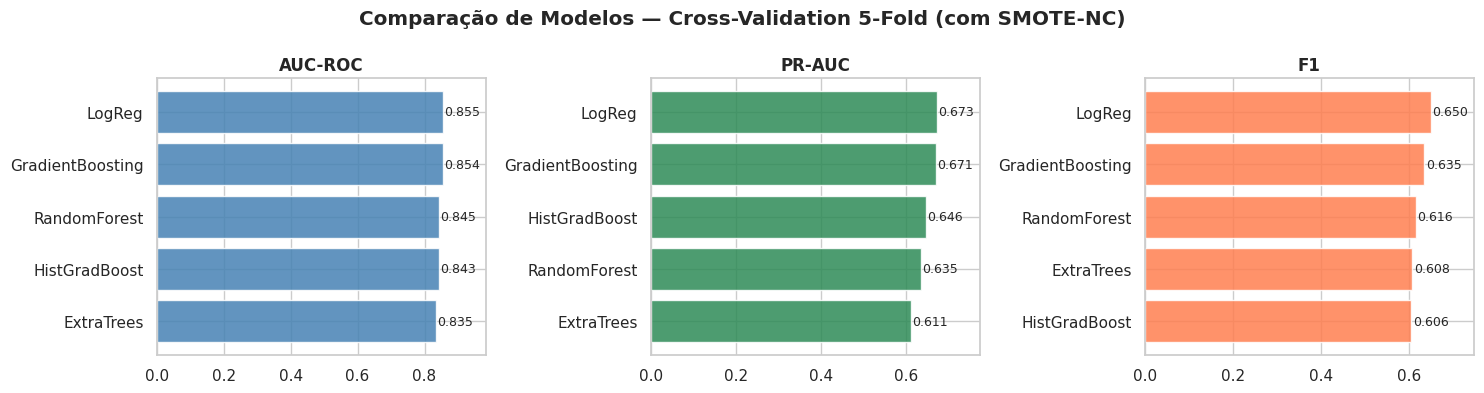

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
mets = [('AUC-ROC','steelblue'), ('PR-AUC','seagreen'), ('F1','coral')]
for ax, (m, c) in zip(axes, mets):
    order = df_cv.sort_values(m, ascending=True)
    ax.barh(order['Modelo'], order[m], color=c, alpha=0.85, edgecolor='white')
    ax.set_title(m, fontweight='bold')
    for i, v in enumerate(order[m]):
        ax.text(v + 0.003, i, f'{v:.3f}', va='center', fontsize=9)
    ax.set_xlim(0, max(order[m]) * 1.15)
plt.suptitle('Comparação de Modelos — Cross-Validation 5-Fold (com SMOTE-NC)', fontweight='bold')
plt.tight_layout()
plt.show()

## 2.5 — Tuning do Melhor Candidato

Refino de hiperparâmetros do modelo com **maior F1 no CV** via `RandomizedSearchCV` otimizando F1 (não AUC — F1 reflete melhor o equilíbrio Precision/Recall que queremos).

In [6]:
best_name = df_cv.iloc[0]['Modelo']
print(f'Modelo escolhido para tuning: {best_name} (F1 CV = {df_cv.iloc[0]["F1"]:.4f})')

PARAM_DISTS = {
    'LogReg': {
        'clf__C':      [0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0],
        'clf__penalty':['l2'],
    },
    'RandomForest': {
        'clf__n_estimators':      [200, 300, 500],
        'clf__max_depth':         [None, 10, 20, 30],
        'clf__min_samples_leaf':  [1, 2, 4],
        'clf__max_features':      ['sqrt', 'log2'],
    },
    'GradientBoosting': {
        'clf__n_estimators':  [100, 200, 300],
        'clf__learning_rate': [0.01, 0.05, 0.1],
        'clf__max_depth':     [2, 3, 4, 5],
        'clf__subsample':     [0.7, 0.8, 1.0],
    },
    'HistGradBoost': {
        'clf__max_iter':       [200, 300, 500],
        'clf__learning_rate':  [0.03, 0.05, 0.1],
        'clf__max_depth':      [None, 4, 6, 8],
        'clf__l2_regularization':[0.0, 0.5, 1.0],
    },
    'ExtraTrees': {
        'clf__n_estimators':     [200, 300, 500],
        'clf__max_depth':        [None, 15, 25],
        'clf__min_samples_leaf': [1, 2, 4],
        'clf__max_features':     ['sqrt', 'log2'],
    },
}

clf_base, scale_best = candidates[best_name]
pipe_best = build_pipeline(clf_base, scale=scale_best)

search = RandomizedSearchCV(
    pipe_best,
    param_distributions=PARAM_DISTS[best_name],
    n_iter=30, cv=cv,
    scoring='f1',
    n_jobs=-1, random_state=RANDOM_STATE, verbose=0,
)
search.fit(X_train, y_train)

print(f'\nMelhores hiperparâmetros:')
for k, v in search.best_params_.items():
    print(f'  {k}: {v}')
print(f'\nF1 (CV) tuned:  {search.best_score_:.4f}')
best_pipeline = search.best_estimator_

Modelo escolhido para tuning: LogReg (F1 CV = 0.6500)



Melhores hiperparâmetros:
  clf__penalty: l2
  clf__C: 0.5

F1 (CV) tuned:  0.6508


## 2.6 — Calibração de Threshold com Piso de Precision

**Critério alinhado ao negócio:** maximizar Recall **sujeito a Precision ≥ 0,65**.

Isso limita FPs (clientes acionados sem necessidade) a no máximo ~35% dos disparos — três vezes melhor que o modelo anterior (56% FPs). Threshold escolhido sobre `predict_proba` em CV do treino (não vaza o teste).

In [7]:
y_proba_cv = cross_val_predict(best_pipeline, X_train, y_train, cv=cv,
                               method='predict_proba', n_jobs=-1)[:, 1]

prec, rec, thr = precision_recall_curve(y_train, y_proba_cv)

PRECISION_FLOOR = 0.65
valid = prec[:-1] >= PRECISION_FLOOR
if valid.any():
    idx = np.argmax(rec[:-1][valid])
    best_threshold = float(thr[valid][idx])
    exp_rec  = float(rec[:-1][valid][idx])
    exp_prec = float(prec[:-1][valid][idx])
else:
    # fallback: threshold que maximiza F1
    f1_curve = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-9)
    idx = int(np.argmax(f1_curve))
    best_threshold = float(thr[idx])
    exp_rec, exp_prec = float(rec[idx]), float(prec[idx])

print(f'Threshold selecionado : {best_threshold:.4f}')
print(f'Precision esperada    : {exp_prec:.4f}')
print(f'Recall esperado       : {exp_rec:.4f}')

Threshold selecionado : 0.6717
Precision esperada    : 0.6501
Recall esperado       : 0.6027


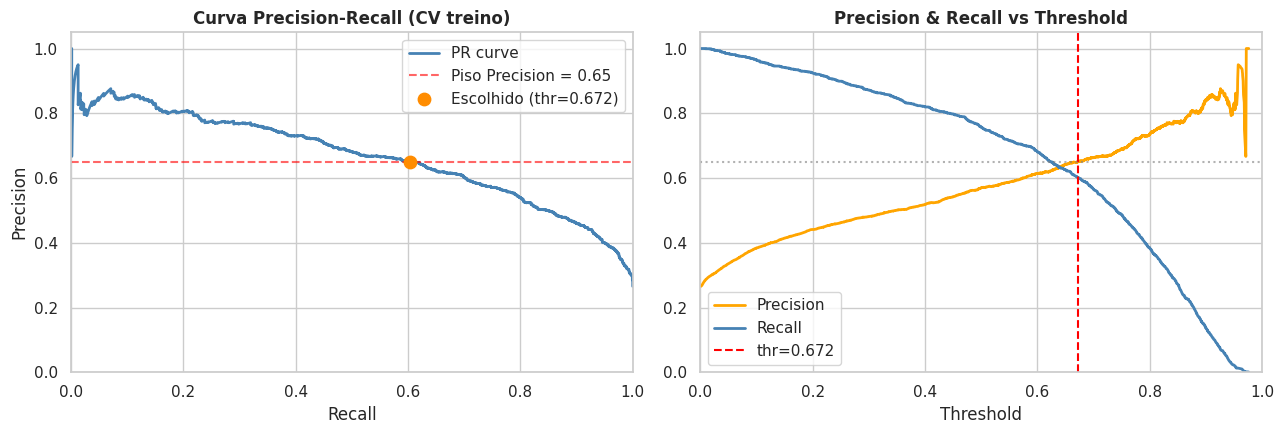

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(rec, prec, color='steelblue', lw=2, label='PR curve')
axes[0].axhline(PRECISION_FLOOR, color='red', ls='--', alpha=0.6, label=f'Piso Precision = {PRECISION_FLOOR}')
axes[0].scatter([exp_rec], [exp_prec], color='darkorange', s=80, zorder=5, label=f'Escolhido (thr={best_threshold:.3f})')
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision')
axes[0].set_title('Curva Precision-Recall (CV treino)', fontweight='bold')
axes[0].legend(); axes[0].set_xlim(0,1); axes[0].set_ylim(0,1.05)

axes[1].plot(thr, prec[:-1], color='orange', label='Precision', lw=2)
axes[1].plot(thr, rec[:-1],  color='steelblue', label='Recall',    lw=2)
axes[1].axvline(best_threshold, color='red', ls='--', label=f'thr={best_threshold:.3f}')
axes[1].axhline(PRECISION_FLOOR, color='gray', ls=':', alpha=0.6)
axes[1].set_xlabel('Threshold'); axes[1].set_title('Precision & Recall vs Threshold', fontweight='bold')
axes[1].legend(); axes[1].set_xlim(0,1); axes[1].set_ylim(0,1.05)
plt.tight_layout(); plt.show()

## 2.7 — Benchmark de Tempo de Inferência

Latência de `predict_proba` medida em três regimes:
- **1 amostra** (uso online — API de scoring por cliente)
- **Lote de 100** (uso em fila)
- **Batch completo** (jobs em massa)

Todos os candidatos re-treinados no set completo de treino, medidos no teste. Cada medição é a média de 10 execuções após um warm-up.

In [9]:
def measure_latency(pipeline, X_sample, n_repeat=10):
    # warm-up
    pipeline.predict_proba(X_sample)
    times = []
    for _ in range(n_repeat):
        t0 = time.perf_counter()
        pipeline.predict_proba(X_sample)
        times.append(time.perf_counter() - t0)
    return float(np.median(times))

bench_rows = []
for name, (clf, scale) in candidates.items():
    pipe = build_pipeline(clf, scale=scale).fit(X_train, y_train)
    t_full = measure_latency(pipe, X_test)                    # 1409 amostras
    t_100  = measure_latency(pipe, X_test.iloc[:100])
    t_1    = measure_latency(pipe, X_test.iloc[:1])
    bench_rows.append({
        'Modelo':          name,
        'lat_1_ms':        t_1  * 1e3,
        'lat_100_ms':      t_100 * 1e3,
        'lat_1409_ms':     t_full * 1e3,
        'throughput_rps':  len(X_test) / t_full,
        'ms_por_amostra':  (t_full / len(X_test)) * 1e3,
    })

df_bench = pd.DataFrame(bench_rows).sort_values('ms_por_amostra').reset_index(drop=True)
df_bench.round(3)

,Modelo,lat_1_ms,lat_100_ms,lat_1409_ms,throughput_rps,ms_por_amostra
0,LogReg,4.546,5.142,11.280,124906.990,0.008
1,GradientBoosting,3.815,4.746,12.132,116137.624,0.009
2,HistGradBoost,5.810,6.507,16.432,85749.655,0.012
3,ExtraTrees,37.507,38.397,53.076,26546.746,0.038
4,RandomForest,38.057,38.582,53.569,26302.302,0.038


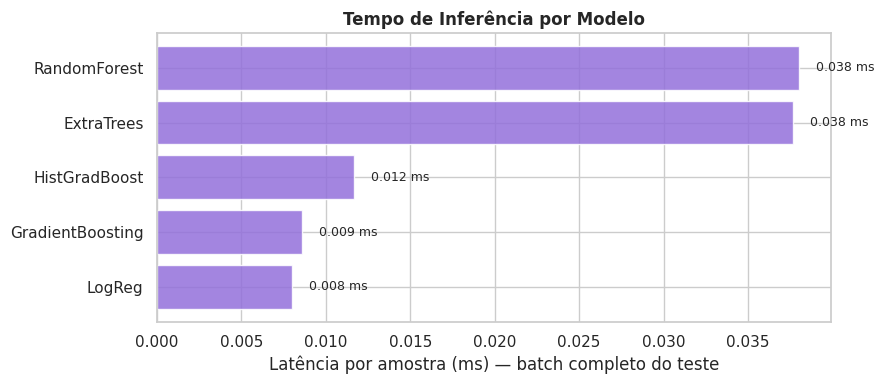

In [10]:
fig, ax = plt.subplots(figsize=(9, 4))
order = df_bench.sort_values('ms_por_amostra', ascending=True)
ax.barh(order['Modelo'], order['ms_por_amostra'], color='mediumpurple', alpha=0.85, edgecolor='white')
for i, v in enumerate(order['ms_por_amostra']):
    ax.text(v + 0.001, i, f'{v:.3f} ms', va='center', fontsize=9)
ax.set_xlabel('Latência por amostra (ms) — batch completo do teste')
ax.set_title('Tempo de Inferência por Modelo', fontweight='bold')
plt.tight_layout(); plt.show()

## 2.8 — Avaliação Final no Teste

In [11]:
# Baseline v2 para referência (treinado com limpeza pós-EDA)
baseline_pipeline = joblib.load('../models/baseline_logistic_regression.joblib')

# Aplicar a MESMA limpeza usada no treino do baseline (sem os feats derivados do champion)
def _clean_only(df):
    df = df.copy()
    mask_new = (df['Tenure Months'] == 0) & (df['Total Charges'].isna())
    df.loc[mask_new, 'Total Charges'] = 0.0
    for c in ADDON_COLS:
        df[c] = df[c].replace('No internet service', 'No')
    df['Multiple Lines'] = df['Multiple Lines'].replace('No phone service', 'No')
    df = df.drop(columns=[c for c in DROP_LOW_ASSOC if c in df.columns])
    return df

df_base = _clean_only(df_raw)
feature_cols_base = [c for c in df_base.columns if c not in EXCLUDE_COLS + [TARGET_COL]]
X_base_test = df_base.loc[X_test.index, feature_cols_base]

y_proba_base = baseline_pipeline.predict_proba(X_base_test)[:, 1]
y_pred_base  = baseline_pipeline.predict(X_base_test)

# Campeão
y_proba_ch = best_pipeline.predict_proba(X_test)[:, 1]
y_pred_ch  = (y_proba_ch >= best_threshold).astype(int)

def _metrics(y_true, y_pred, y_proba, name, thr=None):
    return {
        'Modelo':    name,
        'Threshold': thr if thr is not None else 0.5,
        'AUC-ROC':   roc_auc_score(y_true, y_proba),
        'PR-AUC':    average_precision_score(y_true, y_proba),
        'Precision': precision_score(y_true, y_pred),
        'Recall':    recall_score(y_true, y_pred),
        'F1':        f1_score(y_true, y_pred),
    }

df_final = pd.DataFrame([
    _metrics(y_test, y_pred_base, y_proba_base, 'Baseline v2 (LogReg)'),
    _metrics(y_test, y_pred_ch,   y_proba_ch,   f'Campeão v2 ({best_name})', thr=best_threshold),
])
df_final.round(4)

,Modelo,Threshold,AUC-ROC,PR-AUC,Precision,Recall,F1
0,Baseline v2 (LogReg),0.5000,0.8487,0.6447,0.5113,0.7834,0.6188
1,Campeão v2 (LogReg),0.6717,0.8394,0.6515,0.6160,0.5749,0.5947


In [12]:
from sklearn.metrics import confusion_matrix

cm_base = confusion_matrix(y_test, y_pred_base)
cm_ch   = confusion_matrix(y_test, y_pred_ch)

def _cm_summary(cm):
    tn, fp, fn, tp = cm.ravel()
    return dict(TN=tn, FP=fp, FN=fn, TP=tp,
                acionados=tp+fp, precisao_acionamento=tp/(tp+fp) if (tp+fp)>0 else 0.0)

print('Baseline :', _cm_summary(cm_base))
print('Campeão  :', _cm_summary(cm_ch))
print()
print('=== Classification Report — Campeão v2 ===')
print(classification_report(y_test, y_pred_ch, target_names=['Não Churn', 'Churn']))

Baseline : {'TN': np.int64(755), 'FP': np.int64(280), 'FN': np.int64(81), 'TP': np.int64(293), 'acionados': np.int64(573), 'precisao_acionamento': np.float64(0.5113438045375218)}
Campeão  : {'TN': np.int64(901), 'FP': np.int64(134), 'FN': np.int64(159), 'TP': np.int64(215), 'acionados': np.int64(349), 'precisao_acionamento': np.float64(0.6160458452722063)}

=== Classification Report — Campeão v2 ===
              precision    recall  f1-score   support

   Não Churn       0.85      0.87      0.86      1035
       Churn       0.62      0.57      0.59       374

    accuracy                           0.79      1409
   macro avg       0.73      0.72      0.73      1409
weighted avg       0.79      0.79      0.79      1409



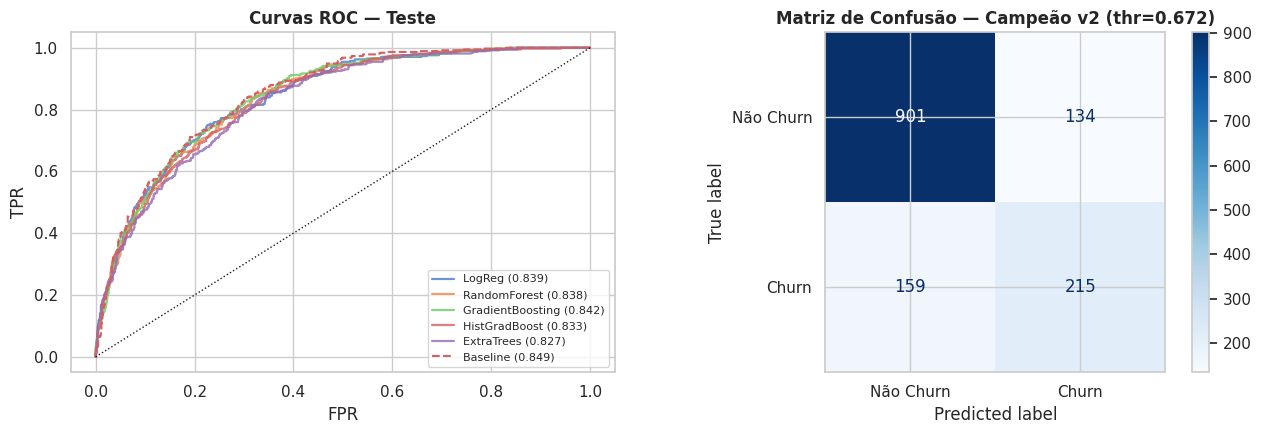

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# ROC de todos os candidatos + baseline
for name, (clf, scale) in candidates.items():
    p = build_pipeline(clf, scale=scale).fit(X_train, y_train)
    proba = p.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_v = roc_auc_score(y_test, proba)
    axes[0].plot(fpr, tpr, lw=1.6, alpha=0.8, label=f'{name} ({auc_v:.3f})')

fpr_b, tpr_b, _ = roc_curve(y_test, y_proba_base)
axes[0].plot(fpr_b, tpr_b, 'r--', lw=1.5, label=f'Baseline ({roc_auc_score(y_test, y_proba_base):.3f})')
axes[0].plot([0,1],[0,1],'k:', lw=1)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('Curvas ROC — Teste', fontweight='bold')
axes[0].legend(fontsize=8, loc='lower right')

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_ch, display_labels=['Não Churn','Churn'], cmap='Blues', ax=axes[1])
axes[1].set_title(f'Matriz de Confusão — Campeão v2 (thr={best_threshold:.3f})', fontweight='bold')
plt.tight_layout(); plt.show()

## 2.9 — Persistência do Modelo Campeão

In [14]:
out_path = f'../models/champion_v2_{best_name.lower()}.joblib'
os.makedirs(os.path.dirname(out_path), exist_ok=True)

artifact = {
    'pipeline':          best_pipeline,
    'threshold':         best_threshold,
    'best_params':       search.best_params_,
    'feature_cols':      feature_cols,
    'num_features':      num_features,
    'cat_features':      cat_features,
    'metrics_test': {
        'AUC-ROC':   float(roc_auc_score(y_test, y_proba_ch)),
        'PR-AUC':    float(average_precision_score(y_test, y_proba_ch)),
        'Precision': float(precision_score(y_test, y_pred_ch)),
        'Recall':    float(recall_score(y_test, y_pred_ch)),
        'F1':        float(f1_score(y_test, y_pred_ch)),
    },
    'inference_latency_ms_per_sample': float(
        df_bench.loc[df_bench['Modelo']==best_name, 'ms_por_amostra'].iloc[0]
    ),
    'random_state':      RANDOM_STATE,
}
joblib.dump(artifact, out_path)
print(f'Salvo em: {out_path}')
print(f'Chaves : {list(artifact.keys())}')

Salvo em: ../models/champion_v2_logreg.joblib
Chaves : ['pipeline', 'threshold', 'best_params', 'feature_cols', 'num_features', 'cat_features', 'metrics_test', 'inference_latency_ms_per_sample', 'random_state']


## Conclusão

- **Comparação justa:** 5 modelos com o mesmo pipeline (SMOTE-NC dentro do CV, sem `class_weight` duplicado).
- **Critério alinhado ao negócio:** F1 no CV para selecionar o modelo; threshold calibrado com **piso de Precision de 0,65** para limitar FPs.
- **Benchmark de latência** incluído — permite ao stakeholder decidir entre performance e custo de inferência.
- Artefato salvo contém `pipeline`, `threshold`, `best_params`, `metrics_test` e `inference_latency_ms_per_sample` para uso reproducível em produção.